In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
df=pd.read_excel('Dataset_9th_Class_Physic_Updated.xlsx')

In [3]:
df.head(20)

,Year,Subject,Chapter,Topic_id,Topic,Question_count,Appeared
0,2025,Physics,Physical Quantities And Measurement,1,Branches Of Physic,1,1.0
1,2025,Physics,Physical Quantities And Measurement,2,Physical Quantities,0,0.0
2,2025,Physics,Physical Quantities And Measurement,3,"International System Of Units (Si Base Units, ...",1,0.0
3,2025,Physics,Physical Quantities And Measurement,4,Standard Form / Scientific Notation,0,0.0
4,2025,Physics,Physical Quantities And Measurement,5,Prefixes (Multiples And Submultiples),0,0.0
5,2025,Physics,Physical Quantities And Measurement,6,Meter Rule,0,0.0
6,2025,Physics,Physical Quantities And Measurement,7,Vernier Caliper,0,0.0
7,2025,Physics,Physical Quantities And Measurement,8,Screw Gauge,0,0.0
8,2025,Physics,Physical Quantities And Measurement,9,Physical Balance,0,0.0
9,2025,Physics,Physical Quantities And Measurement,10,Stop Watch,0,0.0


In [4]:
df.isnull().sum()

Year              0
Subject           0
Chapter           0
Topic_id          0
Topic             0
Question_count    0
Appeared          1
dtype: int64

In [5]:
df[df.isnull().any(axis=1)]

,Year,Subject,Chapter,Topic_id,Topic,Question_count,Appeared
194,2023,Physics,Physical Quantities And Measurement,1,Branches Of Physic,0,NaN


In [6]:
df.fillna(0, inplace=True)

In [7]:
df.isnull().sum()

Year              0
Subject           0
Chapter           0
Topic_id          0
Topic             0
Question_count    0
Appeared          0
dtype: int64

In [8]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)

In [9]:
gaps=[]
last_year_since_appeared={}
for _, row in df.iterrows():
    topic=row['Topic']
    year=int(row['Year'])
    appeared=row['Appeared']
    if topic not in last_year_since_appeared:
        gaps.append(-1)
    else:
        gaps.append(year - last_year_since_appeared[topic])
    if appeared==1:
        last_year_since_appeared[topic]=year
df['Gaps']=gaps

In [10]:
print(df[['Topic', 'Year']].head(20))
print(df['Year'].is_monotonic_increasing)

                                           Topic  Year
0                     Acceleration And Its Types  2016
1                     Acceleration And Its Types  2017
2                     Acceleration And Its Types  2018
3                     Acceleration And Its Types  2019
4                     Acceleration And Its Types  2022
5                     Acceleration And Its Types  2023
6                     Acceleration And Its Types  2024
7                     Acceleration And Its Types  2025
8   Acceleration And Tension In Atwood'S Machine  2016
9   Acceleration And Tension In Atwood'S Machine  2017
10  Acceleration And Tension In Atwood'S Machine  2018
11  Acceleration And Tension In Atwood'S Machine  2019
12  Acceleration And Tension In Atwood'S Machine  2022
13  Acceleration And Tension In Atwood'S Machine  2023
14  Acceleration And Tension In Atwood'S Machine  2024
15  Acceleration And Tension In Atwood'S Machine  2025
16                     Addition Of Forces/Vector  2016
17        

In [11]:
df['Appeared'] = df['Appeared'].fillna(0).astype(int)

In [12]:
df.isnull().sum()

Year              0
Subject           0
Chapter           0
Topic_id          0
Topic             0
Question_count    0
Appeared          0
Gaps              0
dtype: int64

In [13]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    topic = row['Topic']
    year = row['Year']
    
    # Pichle 5 available years nikalo (current year se pehle)
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    # Us topic ki un years mein appeared values nikalo
    topic_data = df[df['Topic'] == topic]
    count = topic_data[topic_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [14]:
df.to_excel('Dataset_9th_Class_Updated_3.xlsx', index=False)

In [15]:
df.columns

Index(['Year', 'Subject', 'Chapter', 'Topic_id', 'Topic', 'Question_count',
       'Appeared', 'Gaps', 'Frequency_Last_5'],
      dtype='object')

### Modeling

In [16]:
df_model = df.drop(['Subject', 'Chapter','Question_count', 'Topic'], axis=1)

In [17]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Topic_id', 'Gaps', 'Frequency_Last_5']
target = 'Appeared'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
probs = model.predict_proba(X_test)[:,1]
preds = (probs > 0.4).astype(int)

### Classification Report and Accuracy

In [20]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test,preds))
print(classification_report(y_test, preds))

Accuracy: 0.7628865979381443
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        72
           1       0.54      0.56      0.55        25

    accuracy                           0.76        97
   macro avg       0.69      0.70      0.69        97
weighted avg       0.77      0.76      0.76        97



In [21]:
test['Predicted'] =preds

print(test[['Topic_id', 'Predicted']][test['Predicted'] == 1])

     Topic_id  Predicted
47         68          1
63          1          1
87         40          1
111        92          1
127        47          1
159        23          1
167        63          1
183        57          1
207        48          1
215        90          1
255        35          1
271        53          1
367        50          1
375        30          1
391        62          1
399        61          1
407        52          1
463        51          1
495         2          1
503        59          1
519         5          1
535        95          1
551        44          1
567        15          1
671        36          1
767        56          1


C:\Users\aliah\AppData\Local\Temp\ipykernel_19348\873470363.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predicted'] =preds


In [22]:
result = df[df['Year'] == 2025].copy()
result['Predicted'] = preds
print(result[result['Predicted'] == 1][['Topic_id', 'Topic']])

     Topic_id                                              Topic
47         68                               Atmospheric Pressure
63          1                                 Branches Of Physic
87         40                                  Centripetal Force
111        92  Conduction Of Heat And Its Mechanism And Appli...
127        47                                             Couple
159        23                                Distance Time Graph
167        63                                         Efficiency
183        57                               Energy And Its Forms
207        48                              Equilibrium And Types
215        90                              Evaporation Of Liquid
255        35                                           Friction
271        53                                Gravitational Field
367        50                       Law Of Universal Gravitation
375        30                                    Linear Momentum
391        62            

In [23]:
df=df.sort_values(by=['Topic','Year'])
df['Appeared_last_year']=df.groupby('Topic')['Appeared'].shift(1)
df['Appeared_last_year']=df['Appeared_last_year'].fillna(0)

In [24]:
df=df.sort_values(by=['Topic','Year'])

In [25]:
df['last_year']=df.groupby('Topic')['Appeared'].shift(1)
df['second_last_year']=df.groupby('Topic')['Appeared'].shift(2)

In [26]:
df['trend']=df['last_year'] - df['second_last_year']
df['trend']=df['trend'].fillna(0)

In [27]:
df.drop(columns=['last_year','second_last_year'],inplace=True)

In [28]:
df=df.sort_values(by=['Topic','Year'])

In [29]:
df['rolling_3'] = (df.groupby('Topic')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum()))

df['rolling_3'] = df['rolling_3'].fillna(0)

In [30]:
df['rolling_3']=df['rolling_3'].fillna(0)

In [31]:
print(df[df['Year'] == 2025]['Gaps'].value_counts())

Gaps
-1    32
 1    24
 2    19
 6     7
 8     5
 3     4
 9     3
 7     3
Name: count, dtype: int64


In [32]:
weight_dict={'Kinematics':0.12
             , 'Dynamics':0.14
             , 'Turning Effect Of Forces':0.12
             ,'Thermal Properties Of Matter':0.14
            , 'Properties Of Matter':0.10
             ,'Physical Quantities And Measurement':0.12
              , 'Transfer Of Heat':0.06,
            'Work And Energy':0.10
            , 'Gravitation':0.10
            }

In [33]:
df['chapter_weight']=df['Chapter'].map(weight_dict)

In [34]:
df.to_excel('Dataset_9th_Class_Physic_Updated_3.xlsx', index=False)

In [35]:
df_model=df.copy()

## Train Test Split
Here we'll experiment to check how well our model understands pattern that's why we train data on ```2024,2023,2022,2019,2018,2017,2016``` and test on the paper of ```2025```

In [36]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

## Baseline Model
  ### ***. LogisticRegression***

In [37]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(class_weight='balanced',random_state=42)
lr_model.fit(X_train,y_train)
lr_predict=lr_model.predict(X_test)

### Accuracy , Precision , Recall

In [38]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
accuracy_lr=accuracy_score(y_test,lr_predict)
precision_lr=precision_score(y_test,lr_predict)
recall_lr=recall_score(y_test,lr_predict)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  71.13%
Precision:46.81%
Recall:88.00%


### Accuarcy , Classification Report On Different Threshold

In [39]:
from sklearn.metrics import classification_report

y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:71.13%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.94      0.65      0.77        72
           1       0.47      0.88      0.61        25

    accuracy                           0.71        97
   macro avg       0.70      0.77      0.69        97
weighted avg       0.82      0.71      0.73        97

Accuracy:54.64%

Threshold=0.4
              precision    recall  f1-score   support

           0       0.94      0.42      0.58        72
           1       0.35      0.92      0.51        25

    accuracy                           0.55        97
   macro avg       0.65      0.67      0.54        97
weighted avg       0.79      0.55      0.56        97

Accuracy:25.77%

Threshold=0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.26      1.00      0.41        25

    accuracy                           0.26        97
   macro avg       0.13      0.50  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Essemble Model
### ***. Random Forest***

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced',n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred=rf_model.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
print(f'Accuarcy:{rf_accuracy*100:.2f}%')
print(f'Precision:{rf_precision*100:.2f}%')
print(f'Recall:{rf_recall*100:.2f}%')

Accuarcy:63.92%
Precision:34.38%
Recall:44.00%


In [42]:
# Training accuracy vs test accuracy compare karo
lr_train_acc = lr_model.score(X_train, y_train)
rf_train_acc = rf_model.score(X_train, y_train)
print(f"LR Train: {lr_train_acc:.2f}, RF Train: {rf_train_acc:.2f}")

LR Train: 0.68, RF Train: 0.77


#### Accuracy and Classification Report on different Threshold

In [43]:
from sklearn.metrics import classification_report, accuracy_score
prob = rf_model.predict_proba(X_test)[:,1]
for t in[0.5,0.4,0.3,0.25]:
    pred=(prob>t).astype(int)
    print("Accuracy:", accuracy_score(y_test,pred))
    print(f'Threshold={t}',classification_report(y_test,pred))

Accuracy: 0.6391752577319587
Threshold=0.5               precision    recall  f1-score   support

           0       0.78      0.71      0.74        72
           1       0.34      0.44      0.39        25

    accuracy                           0.64        97
   macro avg       0.56      0.57      0.57        97
weighted avg       0.67      0.64      0.65        97

Accuracy: 0.6701030927835051
Threshold=0.4               precision    recall  f1-score   support

           0       0.84      0.68      0.75        72
           1       0.41      0.64      0.50        25

    accuracy                           0.67        97
   macro avg       0.63      0.66      0.63        97
weighted avg       0.73      0.67      0.69        97

Accuracy: 0.422680412371134
Threshold=0.3               precision    recall  f1-score   support

           0       0.79      0.31      0.44        72
           1       0.28      0.76      0.40        25

    accuracy                           0.42        97


## Boosting Model
### ***. XGBoost***

In [44]:
from xgboost import XGBClassifier
xg_model = XGBClassifier(scale_pos_weight=3, random_state=42)
xg_model.fit(X_train, y_train)
xg_pred=xg_model.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
xg_accuracy=accuracy_score(y_test,xg_pred)
xg_precision=precision_score(y_test,xg_pred)
xg_recall=recall_score(y_test,xg_pred)
print(f'Accuracy:{xg_accuracy*100:.2f}%')
print(f'Precison:{xg_precision*100:.2f}%')
print(f'Recall:{xg_recall*100:.2f}%')

Accuracy:64.95%
Precison:37.14%
Recall:52.00%


### Accuracy and Classification Report On Different Threshold

In [46]:
prob =xg_model.predict_proba(X_test)[:,1]

for t in [0.5, 0.4, 0.3, 0.25]:
    pred = (prob > t).astype(int)
    print("Accuracy:", accuracy_score(y_test, pred))
    print(f'Threshold={t}', classification_report(y_test, pred))

Accuracy: 0.6494845360824743
Threshold=0.5               precision    recall  f1-score   support

           0       0.81      0.69      0.75        72
           1       0.37      0.52      0.43        25

    accuracy                           0.65        97
   macro avg       0.59      0.61      0.59        97
weighted avg       0.69      0.65      0.67        97

Accuracy: 0.5979381443298969
Threshold=0.4               precision    recall  f1-score   support

           0       0.80      0.61      0.69        72
           1       0.33      0.56      0.42        25

    accuracy                           0.60        97
   macro avg       0.57      0.59      0.56        97
weighted avg       0.68      0.60      0.62        97

Accuracy: 0.36082474226804123
Threshold=0.3               precision    recall  f1-score   support

           0       0.67      0.28      0.39        72
           1       0.22      0.60      0.33        25

    accuracy                           0.36        9

In [47]:
comparison=pd.DataFrame({
    'Accuracy':[accuracy_lr*100,rf_accuracy*100,xg_accuracy*100],
    'Precision':[precision_lr*100,rf_precision*100,xg_precision*100],
    'Recall':[recall_lr*100,rf_recall*100,xg_recall*100] 
},index=['LogisticRegression','Random Forest','XGBoost'])
comparison=comparison.round(2)

In [48]:
print("\t=== Comparison of Models ===")
print(comparison)

	=== Comparison of Models ===
                    Accuracy  Precision  Recall
LogisticRegression     71.13      46.81    88.0
Random Forest          63.92      34.38    44.0
XGBoost                64.95      37.14    52.0


In [49]:
print(features)

['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']


In [51]:
print(df.columns.tolist())

['Year', 'Subject', 'Chapter', 'Topic_id', 'Topic', 'Question_count', 'Appeared', 'Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'trend', 'rolling_3', 'chapter_weight']


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Topic_id', 'Topic', 'Chapter', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Topic_id', 'Topic', 'Chapter', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Physics_9th_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Topic_id                                              Topic  \
0         92  Conduction Of Heat And Its Mechanism And Appli...   
1         55                    Motion Of Artificial Satellites   
2         70                                    Liquid Pressure   
3         48                              Equilibrium And Types   
4         15                                Scalars And Vectors   
5         94  Convection Of Heat And Its Mechanism and Appli...   
6         62                            Major Sources Of Energy   
7         52                                      Mass Of Earth   
8         61                            Mass Energy Equivalence   
9         50                       Law Of Universal Gravitation   
10        14                         Motion and Types Of Motion   
11        44                        Resolution Of Forces/Vector   
12        63                                         Efficiency   
13        58                                     Kinetic Energ

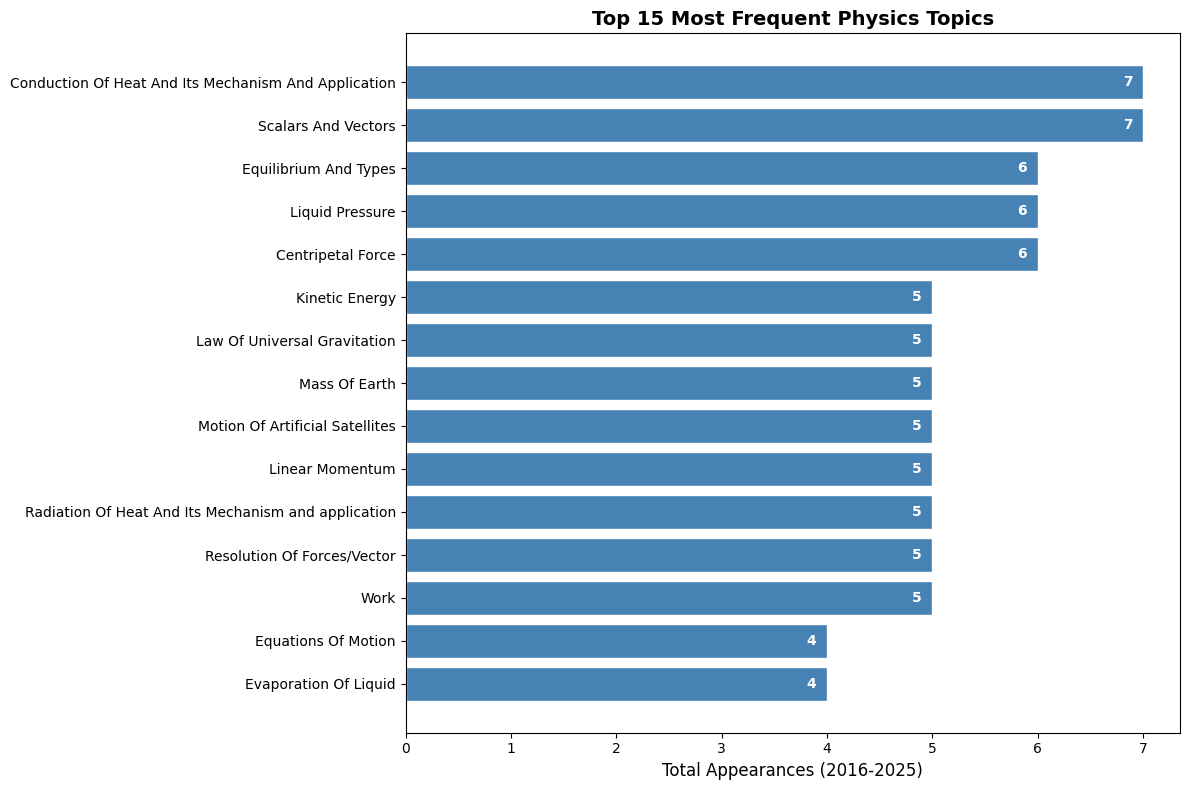

In [ ]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Physics Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

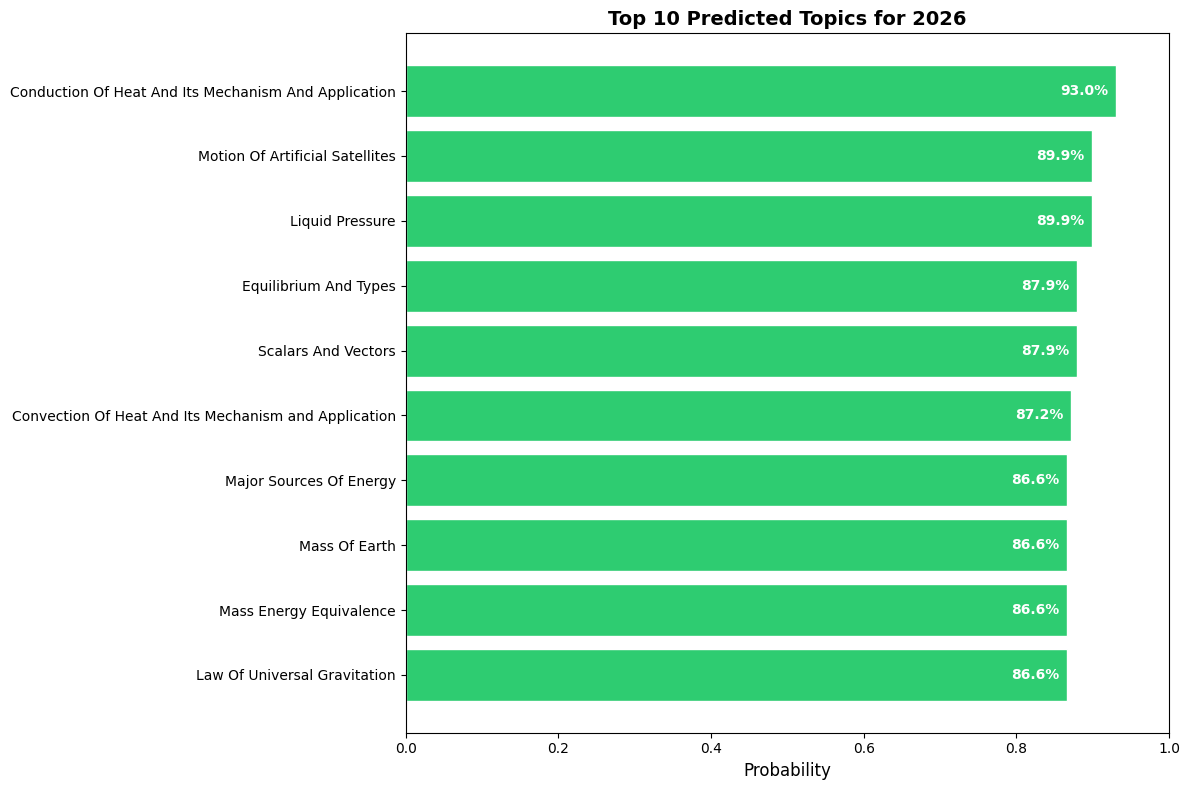

In [ ]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Topic'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()

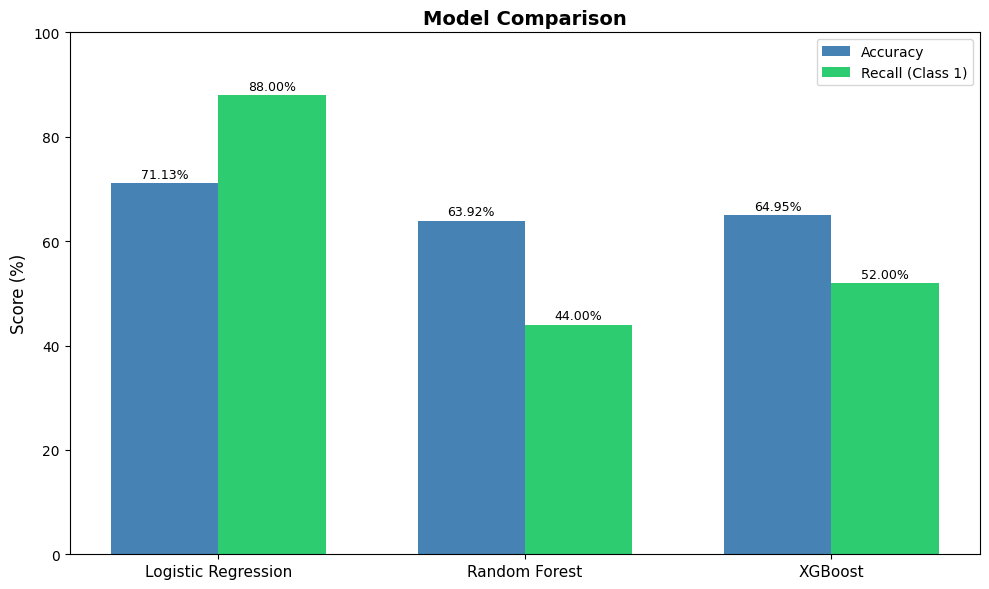

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [accuracy_lr*100, rf_accuracy*100, xg_accuracy*100]
recall = [recall_lr*100, rf_recall*100, xg_recall*100]

x = range(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], accuracy, width, label='Accuracy', color='steelblue')
plt.bar([i + width/2 for i in x], recall, width, label='Recall (Class 1)', color='#2ecc71')

plt.ylabel('Score (%)', fontsize=12)
plt.title('Model Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, models, fontsize=11)
plt.legend()
plt.ylim(0, 100)

for i, (acc, rec) in enumerate(zip(accuracy, recall)):
    plt.text(i - width/2, acc + 1, f'{acc:.2f}%', ha='center', fontsize=9)
    plt.text(i + width/2, rec + 1, f'{rec:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('graph3_model_comparison.png', dpi=150)
plt.show()

### Walk Forward Validation

In [ ]:
from sklearn.metrics import recall_score, accuracy_score

years = [2023, 2024, 2025]
results = []

for test_year in years:
    train = df_model[df_model['Year'] < test_year]
    test = df_model[df_model['Year'] == test_year]
    
    X_tr, y_tr = train[features], train[targets]
    X_te, y_te = test[features], test[targets]
    
    scaler_wf = StandardScaler()
    X_tr_scaled = scaler_wf.fit_transform(X_tr)
    X_te_scaled = scaler_wf.transform(X_te)
    
    model_wf = LogisticRegression(class_weight='balanced', random_state=42)
    model_wf.fit(X_tr_scaled, y_tr)
    y_pred = model_wf.predict(X_te_scaled)
    
    results.append({
        'Test Year': test_year,
        'Accuracy': round(accuracy_score(y_te, y_pred) * 100, 2),
        'Recall': round(recall_score(y_te, y_pred) * 100, 2)
    })

print(pd.DataFrame(results))

   Test Year  Accuracy  Recall
0       2023     53.61   64.29
1       2024     53.61   79.17
2       2025     64.95   92.00


"Walk-forward validation confirm karta hai ke model data ke saath improve hota hai. 2025 pe 92% recall — jo sabse zyada training data wala split hai — yeh show karta hai ke jaise dataset grow karega, model better hoga. Limited 8-year dataset is project ki core limitation hai."

In [ ]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.7423


In [ ]:
import pandas as pd

# Original dataset load karo
# df_original = pd.read_excel('Biology_9th.xlsx')  # original file

# Predicted topics
predicted_topics = final_predictions['Topic'].tolist()

# Har predicted topic ke liye years nikalo
results = []
for _, row in final_predictions.iterrows():
    topic = row['Topic']
    prob = row['Probability']
    category = row['Category']
    
    # Is topic ke sab years nikalo jahan Appeared == 1
    appeared_years = df[
        (df['Topic'] == topic) & 
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years = sorted(appeared_years)
    
    results.append({
        'Topic': topic,
        'Probability': round(prob, 4),
        'Category': category,
        'Years_Appeared': ', '.join(map(str, appeared_years)),
        'Total_Appearances': len(appeared_years)
    })

result_df = pd.DataFrame(results)
result_df.to_excel('Biology_9th_Predictions_Detailed_2026.xlsx', index=False)
print(result_df)

FileNotFoundError: [Errno 2] No such file or directory: 'Biology_9th.xlsx'